<a href="https://colab.research.google.com/github/JanaHAlharbi/jaundice-screening-mobilenetv2/blob/main/jaundice_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Newborn jaundice screening from photos

Capstone project notebook. It trains a MobileNetV2 classifier on the NJN dataset (normal vs jaundice) and ends with a demo page where you upload a photo and get a prediction with a Grad-CAM heatmap.

**Before you run anything**

1. Turn on the GPU: `Runtime` > `Change runtime type` > `T4 GPU`.
2. Put the dataset in your Google Drive in a folder named `NJN`, so the path is `MyDrive/NJN`. The images must sit in two folders, one with `normal` in its name and one with `jaund` in its name (for example `normal` and `jaundice`).
3. Run the cells from top to bottom.

This is a screening aid for a student project. It is not a medical diagnosis.

## Step 1: Setup

Installs Gradio (for the demo page) and connects your Google Drive. A pop-up will ask for permission.

In [1]:
!pip install gradio -q

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Step 2: Imports and settings

All the settings you may want to change are in this cell.

- `USE_WHITE_BALANCE` and `USE_SKIN_MASK` are the two preprocessing experiments. Leave both `False` for your first run (the baseline).
- Change `RUN_NAME` each time you try a new combination, so the results are logged under a different name.

In [2]:
import os, glob, hashlib, random, shutil
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ---------- Settings ----------
DATA_DIR  = "/content/drive/MyDrive/NJN"                # dataset folder in your Drive
WORK_DIR  = "/content/drive/MyDrive/jaundice_project"   # results are saved here
LOCAL_RAW = "/content/NJN_raw"                          # fast local copy of the dataset
CACHE_DIR = "/content/processed"                        # preprocessed images

USE_WHITE_BALANCE = False    # experiment 1: correct the lighting
USE_SKIN_MASK     = False    # experiment 2: keep skin pixels only
RUN_NAME          = "nomask_ft2_focal"

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 20
SEED       = 42
CLASSES    = ["jaundice", "normal"]   # alphabetical, the order ImageFolder uses

os.makedirs(WORK_DIR, exist_ok=True)
BEST_PATH = os.path.join(WORK_DIR, f"best_{RUN_NAME}.pt")

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


## Step 3: Copy the dataset and look at its folders

Reading images straight from Drive is slow, so this copies the dataset to Colab's own disk once. Then it prints the folder structure so you can check that it looks right.

In [3]:
assert os.path.exists(DATA_DIR), f"Folder not found: {DATA_DIR}. Check the name in your Drive."

if not os.path.exists(LOCAL_RAW):
    shutil.copytree(DATA_DIR, LOCAL_RAW)

for root, dirs, files in os.walk(LOCAL_RAW):
    depth = root.replace(LOCAL_RAW, "").count(os.sep)
    if depth <= 2:
        print("  " * depth + os.path.basename(root) + f"/  ({len(files)} files)")

NJN_raw/  (4 files)
  normal/  (560 files)
  jaundice/  (200 files)


## Step 4: Build the list of images and labels

The label comes from the name of the folder that holds each image: `jaund...` means jaundice, `normal` means normal. Check that the two counts printed below match what you expect (about 200 jaundice and 560 normal).

In [4]:
IMAGE_EXT = (".jpg", ".jpeg", ".png", ".bmp")

rows = []
for path in sorted(glob.glob(os.path.join(LOCAL_RAW, "**", "*"), recursive=True)):
    if not path.lower().endswith(IMAGE_EXT):
        continue
    folder = os.path.basename(os.path.dirname(path)).lower()
    is_jaundice, is_normal = "jaund" in folder, "normal" in folder
    if is_jaundice == is_normal:      # folder name is unclear, skip it
        continue
    rows.append({"path": path, "label": "jaundice" if is_jaundice else "normal"})

df = pd.DataFrame(rows, columns=["path", "label"])
assert len(df) > 0, "No labelled images found. Put the images in two folders named 'normal' and 'jaundice'."
print(df["label"].value_counts())

label
normal      560
jaundice    200
Name: count, dtype: int64


## Step 5: Clean the data

Removes files that cannot be opened and exact duplicate files.

In [5]:
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

readable = df["path"].apply(lambda p: cv2.imread(p) is not None)
print("Unreadable images removed:", int((~readable).sum()))
df = df[readable].copy()

df["hash"] = df["path"].apply(file_hash)
before = len(df)
df = df.drop_duplicates("hash").drop(columns="hash").reset_index(drop=True)
print("Exact duplicates removed:", before - len(df))
print(df["label"].value_counts())

Unreadable images removed: 0
Exact duplicates removed: 5
label
normal      558
jaundice    197
Name: count, dtype: int64


## Step 6: Look at some images

Always look at the data with your own eyes before training. Notice the lighting, the backgrounds, and how much of each photo is skin.

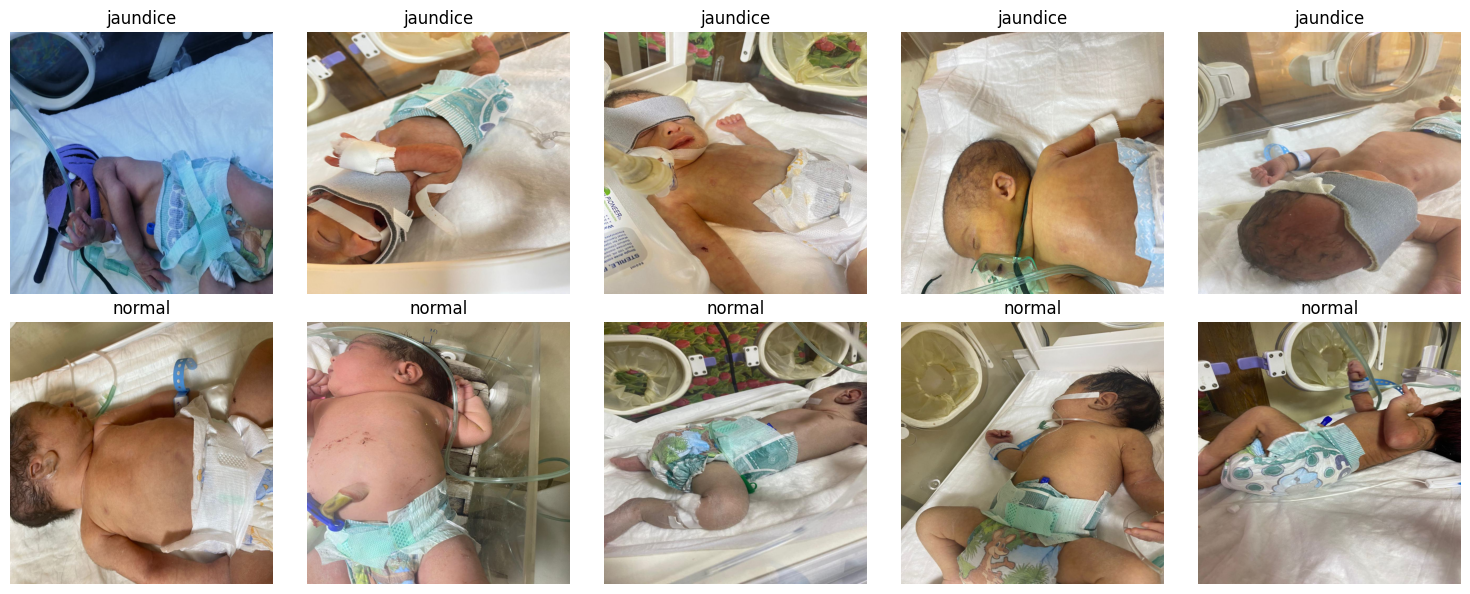

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for r, cls in enumerate(CLASSES):
    sample = df[df["label"] == cls].sample(5, random_state=SEED)
    for ax, p in zip(axes[r], sample["path"]):
        ax.imshow(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB))
        ax.set_title(cls); ax.axis("off")
plt.tight_layout(); plt.show()

## Step 7: Preprocessing functions

*   List item
*   List item



- `white_balance`: gray-world correction. It scales the colour channels so their averages match, which reduces the effect of yellow or blue room lighting. It runs on the full image, before any masking, so the background can act as a lighting reference.
- `skin_mask`: keeps skin-coloured pixels using thresholds in the YCrCb colour space and blacks out the rest. If it finds very little skin, it leaves the image unchanged.
- `preprocess`: the single function used everywhere (training, testing, and the demo), so every image is treated the same way.

In [7]:
def white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    means = img.reshape(-1, 3).mean(axis=0)
    gain = means.mean() / (means + 1e-6)
    return np.clip(img * gain, 0, 255).astype(np.uint8)

def skin_mask(img_bgr):
    ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(ycrcb, (0, 135, 70), (255, 180, 130))
    mask = cv2.bitwise_and(mask, cv2.inRange(hsv, (0, 40, 60), (180, 255, 255)))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    if mask.mean() / 255 < 0.10:
        return img_bgr
    return cv2.bitwise_and(img_bgr, img_bgr, mask=mask)

def preprocess(img_bgr):
    if USE_WHITE_BALANCE:
        img_bgr = white_balance(img_bgr)
    img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    if USE_SKIN_MASK:
        img_bgr = skin_mask(img_bgr)
    return img_bgr

### See what each preprocessing step does

Each row is one image: original, white balance, skin mask, and both together. Use this to judge whether the steps help or damage the images. Watch whether white balance removes the yellow tone of jaundiced skin.

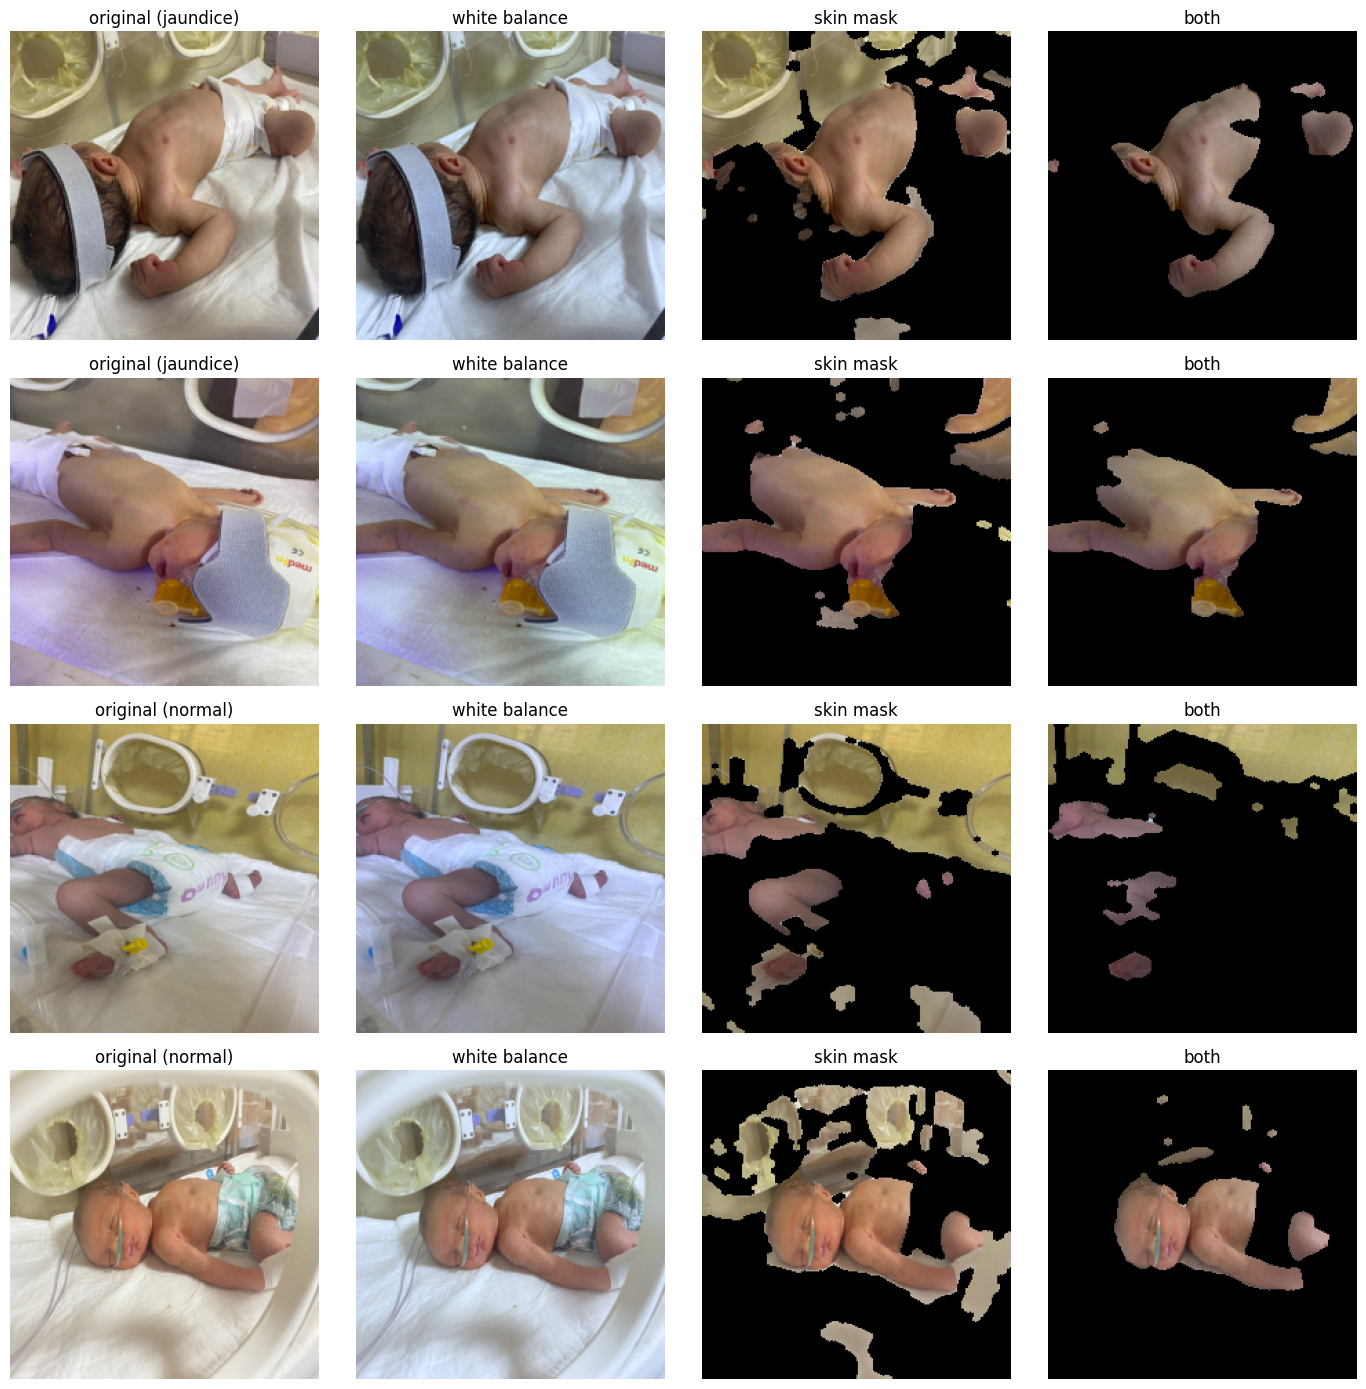

In [8]:
def show(ax, img_bgr, title):
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); ax.set_title(title); ax.axis("off")

sample = pd.concat([df[df["label"] == c].sample(2, random_state=1) for c in CLASSES])
fig, axes = plt.subplots(len(sample), 4, figsize=(14, 3.5 * len(sample)))
for row_axes, item in zip(axes, sample.itertuples()):
    small = cv2.resize(cv2.imread(item.path), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    wb = cv2.resize(white_balance(cv2.imread(item.path)), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    show(row_axes[0], small, f"original ({item.label})")
    show(row_axes[1], wb, "white balance")
    show(row_axes[2], skin_mask(small), "skin mask")
    show(row_axes[3], skin_mask(wb), "both")
plt.tight_layout(); plt.show()

## Step 8: Split into train, validation and test

70 / 15 / 15, stratified so each part keeps the same share of jaundice images. The split happens before augmentation, and the test part is only used once at the end.

In [9]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

splits = {"train": train_df, "val": val_df, "test": test_df}
for name, part in splits.items():
    print(f"{name:5s} {len(part):4d} images  {part['label'].value_counts().to_dict()}")

train  528 images  {'normal': 390, 'jaundice': 138}
val    113 images  {'normal': 84, 'jaundice': 29}
test   114 images  {'normal': 84, 'jaundice': 30}


## Step 9: Apply the preprocessing and save the result

Every image goes through `preprocess` once and is saved to `CACHE_DIR`, in folders the training code can read directly.

In [10]:
if os.path.exists(CACHE_DIR):
    shutil.rmtree(CACHE_DIR)

for split, part in splits.items():
    for cls in CLASSES:
        os.makedirs(os.path.join(CACHE_DIR, split, cls), exist_ok=True)
    for i, item in enumerate(part.itertuples()):
        out = preprocess(cv2.imread(item.path))
        cv2.imwrite(os.path.join(CACHE_DIR, split, item.label, f"{i:04d}.png"), out)

print("Preprocessing done. White balance:", USE_WHITE_BALANCE, "| Skin mask:", USE_SKIN_MASK)

Preprocessing done. White balance: False | Skin mask: False


## Step 10: Normalization, augmentation and data loaders

- Normalization uses the ImageNet values, which the pre-trained model requires.
- Augmentation (random crop, flip, small rotation) applies to the training images only.
- There is no colour augmentation on purpose, because colour is the sign of jaundice.

In [11]:
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2)),
])
test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.ImageFolder(os.path.join(CACHE_DIR, "train"), train_tf)
val_ds   = datasets.ImageFolder(os.path.join(CACHE_DIR, "val"), test_tf)
test_ds  = datasets.ImageFolder(os.path.join(CACHE_DIR, "test"), test_tf)
assert train_ds.classes == CLASSES, train_ds.classes

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=2)
test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=2)
print("Class order:", train_ds.class_to_idx)

Class order: {'jaundice': 0, 'normal': 1}


## Step 11: Build the model

MobileNetV2 with ImageNet weights. The backbone is frozen and only the new final layer (2 outputs) is trained. The loss uses class weights, so mistakes on the smaller jaundice class count more.

In [12]:
model = models.mobilenet_v2(weights="IMAGENET1K_V1")
for p in model.features.parameters():
    p.requires_grad = False
model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(1280, 2))
model = model.to(device)

counts = train_df["label"].value_counts()
class_weights = torch.tensor([len(train_df) / (2 * counts[c]) for c in CLASSES], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Class weights:", dict(zip(CLASSES, class_weights.tolist())))

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 94.1MB/s]


Class weights: {'jaundice': 1.91304349899292, 'normal': 0.6769230961799622}


In [13]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight, self.gamma = weight, gamma

    def forward(self, logits, target):
        ce = nn.functional.cross_entropy(logits, target, weight=self.weight, reduction="none")
        p_true = torch.exp(-nn.functional.cross_entropy(logits, target, reduction="none"))
        return ((1 - p_true) ** self.gamma * ce).mean()

criterion = FocalLoss(weight=class_weights, gamma=2.0)

## Step 12: Train

After each epoch the model is checked on the validation set. The best version is saved to your Drive, and training stops early if the validation loss has not improved for 5 epochs. Early stopping is one of the protections against overfitting.

In [ ]:
history = []
state = {"best_val_loss": float("inf")}

def run_epoch(loader, train):
    model.train(train)
    if train:
        model.features.eval()      # keep the backbone's BatchNorm statistics fixed
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct += (out.argmax(1) == y).sum().item()
            n += len(y)
    return total_loss / n, correct / n

def fit(epochs, lr, patience=5):
    global optimizer
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    bad_epochs = 0
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(train_dl, train=True)
        va_loss, va_acc = run_epoch(val_dl, train=False)
        history.append({"train_loss": tr_loss, "val_loss": va_loss, "train_acc": tr_acc, "val_acc": va_acc})
        print(f"Epoch {epoch:2d}  train loss {tr_loss:.3f} acc {tr_acc:.3f} | val loss {va_loss:.3f} acc {va_acc:.3f}")
        if va_loss < state["best_val_loss"]:
            state["best_val_loss"] = va_loss
            torch.save(model.state_dict(), BEST_PATH)
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Early stopping: validation loss stopped improving.")
                break
    model.load_state_dict(torch.load(BEST_PATH, map_location=device))
    print("Best model loaded from", BEST_PATH)

fit(epochs=EPOCHS, lr=1e-3)

Epoch  1  train loss 0.276 acc 0.525 | val loss 0.208 acc 0.717
Epoch  2  train loss 0.201 acc 0.602 | val loss 0.166 acc 0.726
Epoch  3  train loss 0.180 acc 0.614 | val loss 0.155 acc 0.708
Epoch  4  train loss 0.159 acc 0.693 | val loss 0.143 acc 0.717
Epoch  5  train loss 0.167 acc 0.695 | val loss 0.146 acc 0.761
Epoch  6  train loss 0.154 acc 0.720 | val loss 0.143 acc 0.646
Epoch  7  train loss 0.161 acc 0.676 | val loss 0.127 acc 0.717
Epoch  8  train loss 0.142 acc 0.697 | val loss 0.208 acc 0.788
Epoch  9  train loss 0.138 acc 0.765 | val loss 0.168 acc 0.788
Epoch 10  train loss 0.145 acc 0.729 | val loss 0.147 acc 0.814
Epoch 11  train loss 0.144 acc 0.733 | val loss 0.129 acc 0.743


### Optional: fine-tuning

Run this only if the results above are not good enough. It unfreezes the last few blocks of the backbone and trains them with a very small learning rate. Set `FINE_TUNE = True` to use it.

In [ ]:
FINE_TUNE = True

if FINE_TUNE:
    for p in model.features.parameters():
        p.requires_grad = True
    fit(epochs=30, lr=1e-4, patience=7)

## Step 13: Training curves

If the training loss keeps falling while the validation loss rises, the model is overfitting.

In [ ]:
h = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
h[["train_loss", "val_loss"]].plot(ax=axes[0], title="Loss"); axes[0].set_xlabel("epoch")
h[["train_acc", "val_acc"]].plot(ax=axes[1], title="Accuracy"); axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, f"curves_{RUN_NAME}.png"), dpi=150)
plt.show()

## Step 14: Final test

This is the one-time check on images the model has never seen. The number to focus on is the **recall for jaundice**: of the babies who really have jaundice, how many did the model catch. Accuracy alone is misleading here, because a model that always answers "normal" would already score about 74%.

The results are also added to `results_log.csv` in your Drive, one row per experiment.

In [ ]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_dl:
        out = model(x.to(device))
        y_true += y.tolist()
        y_pred += out.argmax(1).cpu().tolist()

print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap="Blues")
plt.title(f"Test set ({RUN_NAME})")
plt.savefig(os.path.join(WORK_DIR, f"confusion_{RUN_NAME}.png"), dpi=150)
plt.show()

tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]     # jaundice is the positive class
result = {
    "run": RUN_NAME, "white_balance": USE_WHITE_BALANCE, "skin_mask": USE_SKIN_MASK,
    "accuracy": (tp + tn) / cm.sum(),
    "jaundice_recall": tp / max(tp + fn, 1),
    "jaundice_precision": tp / max(tp + fp, 1),
    "missed_jaundice": int(fn), "false_alarms": int(fp),
}
log_path = os.path.join(WORK_DIR, "results_log.csv")
pd.DataFrame([result]).to_csv(log_path, mode="a", header=not os.path.exists(log_path), index=False)
pd.read_csv(log_path)

## Step 15: Grad-CAM, where did the model look?

Grad-CAM uses the last 7x7 feature maps to draw a heatmap over the image. Red areas influenced the decision most. You want the heat on the skin. If it sits on the background or the bedding, the model has learned a shortcut.

In [ ]:
def grad_cam(x, class_idx=None):
    model.eval()
    x = x.clone().requires_grad_(True)
    feats = model.features(x)                        # shape [1, 1280, 7, 7]
    feats.retain_grad()
    pooled = nn.functional.adaptive_avg_pool2d(feats, 1).flatten(1)
    logits = model.classifier(pooled)
    if class_idx is None:
        class_idx = logits.argmax(1).item()
    model.zero_grad()
    logits[0, class_idx].backward()
    weights = feats.grad.mean(dim=(2, 3), keepdim=True)
    cam = torch.relu((weights * feats).sum(1))[0]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    probs = torch.softmax(logits, 1)[0]
    return cam.detach().cpu().numpy(), probs.detach().cpu().numpy()

def overlay_cam(img_rgb, cam):
    cam = cv2.resize(cam, (img_rgb.shape[1], img_rgb.shape[0]))
    heat = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return np.uint8(0.55 * img_rgb + 0.45 * heat)

def predict_image(img_bgr):
    proc = preprocess(img_bgr)                       # same preprocessing as training
    rgb = cv2.cvtColor(proc, cv2.COLOR_BGR2RGB)
    x = test_tf(Image.fromarray(rgb)).unsqueeze(0).to(device)
    cam, probs = grad_cam(x)
    return rgb, overlay_cam(rgb, cam), probs

sample = test_df.sample(min(6, len(test_df)), random_state=SEED)
fig, axes = plt.subplots(2, len(sample), figsize=(3.2 * len(sample), 6.5))
for i, item in enumerate(sample.itertuples()):
    rgb, overlay, probs = predict_image(cv2.imread(item.path))
    pred = CLASSES[int(probs.argmax())]
    axes[0, i].imshow(rgb); axes[0, i].set_title(f"true: {item.label}"); axes[0, i].axis("off")
    axes[1, i].imshow(overlay); axes[1, i].set_title(f"pred: {pred} ({probs.max():.0%})"); axes[1, i].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, f"gradcam_{RUN_NAME}.png"), dpi=150)
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

# 1) Turn every image into a list of 1280 numbers (features) using the pre-trained backbone
model.eval()
feats = []
with torch.no_grad():
    for p in df["path"]:
        rgb = cv2.cvtColor(preprocess(cv2.imread(p)), cv2.COLOR_BGR2RGB)
        x = test_tf(Image.fromarray(rgb)).unsqueeze(0).to(device)
        f = nn.functional.adaptive_avg_pool2d(model.features(x), 1).flatten(1)
        feats.append(f.cpu().numpy()[0])
X = StandardScaler().fit_transform(np.array(feats))
print("Feature table:", X.shape)

# 2) K-means groups the images into 2 clusters without seeing the labels
df["cluster"] = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit_predict(X)
share = df.groupby("cluster")["label"].apply(lambda s: (s == "jaundice").mean())
df["cluster_name"] = np.where(df["cluster"] == share.idxmax(), "jaundice-like", "normal-like")

# 3) t-SNE squeezes the 1280 numbers into 2 so the images can be drawn as points
xy = TSNE(n_components=2, perplexity=30, init="pca", random_state=SEED).fit_transform(X)
df["tsne_x"], df["tsne_y"] = xy[:, 0], xy[:, 1]

# 4) Draw the same points twice: coloured by true label, and by K-means cluster
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, col, title in [(axes[0], "label", "True labels"), (axes[1], "cluster_name", "K-means clusters")]:
    for name, colour in [("normal", "tab:blue"), ("jaundice", "tab:orange"),
                         ("normal-like", "tab:blue"), ("jaundice-like", "tab:orange")]:
        part = df[df[col] == name]
        if len(part):
            ax.scatter(part["tsne_x"], part["tsne_y"], s=18, alpha=0.7, c=colour, label=f"{name} ({len(part)})")
    ax.set_title(title); ax.legend(); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f"t-SNE of MobileNetV2 features ({RUN_NAME})")
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, f"tsne_{RUN_NAME}.png"), dpi=150)
plt.show()

print(pd.crosstab(df["label"], df["cluster_name"]))
print("Agreement between clusters and labels (ARI, 1 = perfect, 0 = random):",
      round(adjusted_rand_score(df["label"], df["cluster"]), 3))

In [ ]:
view = df[df["path"].isin(test_df["path"])]

plt.figure(figsize=(7, 6))
for name, colour in [("normal", "tab:blue"), ("jaundice", "tab:orange")]:
    part = view[view["label"] == name]
    plt.scatter(part["tsne_x"], part["tsne_y"], s=28, alpha=0.8, c=colour, label=f"{name} ({len(part)})")
plt.title(f"t-SNE, test images only ({RUN_NAME})")
plt.legend(); plt.xticks([]); plt.yticks([])
plt.savefig(os.path.join(WORK_DIR, f"tsne_test_only_{RUN_NAME}.png"), dpi=150)
plt.show()

In [ ]:
odd = df[(df["label"] == "normal") & (df["cluster_name"] == "jaundice-like")]
print("Normal images that landed in the jaundice-like cluster:", len(odd))

show_n = min(8, len(odd))
if show_n:
    fig, axes = plt.subplots(1, show_n, figsize=(3 * show_n, 3.3), squeeze=False)
    for ax, item in zip(axes[0], odd.sample(show_n, random_state=SEED).itertuples()):
        ax.imshow(cv2.cvtColor(preprocess(cv2.imread(item.path)), cv2.COLOR_BGR2RGB))
        ax.set_title(os.path.basename(item.path), fontsize=8); ax.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, f"normal_in_jaundice_cluster_{RUN_NAME}.png"), dpi=150)
    plt.show()

In [ ]:
rows = []
for item in test_df.itertuples():
    rgb, overlay, probs = predict_image(cv2.imread(item.path))
    rows.append({"path": item.path, "file": os.path.basename(item.path), "true": item.label,
                 "pred": CLASSES[int(probs.argmax())], "p_jaundice": float(probs[0]),
                 "seen": rgb, "overlay": overlay})
res = pd.DataFrame(rows)

errors = res[res["true"] != res["pred"]]
missed = errors[errors["true"] == "jaundice"].sort_values("p_jaundice")
false_alarms = errors[errors["true"] == "normal"].sort_values("p_jaundice", ascending=False)
print("Test images:", len(res), "| Missed jaundice:", len(missed), "| False alarms:", len(false_alarms))

def show_errors(part, title, max_images=8):
    part = part.head(max_images)
    if len(part) == 0:
        print("No images in:", title)
        return
    fig, axes = plt.subplots(3, len(part), figsize=(2.7 * len(part), 8.4), squeeze=False)
    for i, r in enumerate(part.itertuples()):
        original = cv2.cvtColor(cv2.resize(cv2.imread(r.path), (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(original);  axes[0, i].set_title(r.file, fontsize=7)
        axes[1, i].imshow(r.seen);    axes[1, i].set_title("what the model saw", fontsize=8)
        axes[2, i].imshow(r.overlay); axes[2, i].set_title(f"P(jaundice) = {r.p_jaundice:.0%}", fontsize=8)
        for row in range(3):
            axes[row, i].axis("off")
    plt.suptitle(f"{title} ({RUN_NAME})")
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, f"{title.replace(' ', '_')}_{RUN_NAME}.png"), dpi=150)
    plt.show()

show_errors(missed, "Missed jaundice")
show_errors(false_alarms, "False alarms")

errors[["file", "true", "pred", "p_jaundice"]].to_csv(os.path.join(WORK_DIR, f"errors_{RUN_NAME}.csv"), index=False)
errors[["file", "true", "pred", "p_jaundice"]]

## Step 16: Demo page

Upload a photo (or use the camera) and get the prediction with the heatmap. For your presentation, use images from the test set, since the model has not seen them.

`share=True` creates a temporary public link. Do not upload photos of real babies without the parents' consent.

In [ ]:
import gradio as gr

def demo_fn(image):
    if image is None:
        return None, None
    bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    _, overlay, probs = predict_image(bgr)
    return {CLASSES[i]: float(probs[i]) for i in range(len(CLASSES))}, overlay

demo = gr.Interface(
    fn=demo_fn,
    inputs=gr.Image(type="numpy", label="Newborn photo"),
    outputs=[gr.Label(num_top_classes=2, label="Prediction"),
             gr.Image(label="Where the model looked (Grad-CAM)")],
    title="Newborn jaundice screening (student project)",
    description="Screening aid only. This is not a medical diagnosis. Jaundice must be confirmed with a bilirubin test.",
)
demo.launch(share=True)

## Step 17: Run the preprocessing experiments

To measure what each preprocessing step adds, repeat the notebook with different settings in Step 2:

| Run | `RUN_NAME` | `USE_WHITE_BALANCE` | `USE_SKIN_MASK` |
|---|---|---|---|
| 1 | `baseline` | False | False |
| 2 | `wb` | True | False |
| 3 | `mask` | False | True |
| 4 | `wb_mask` | True | True |

For each run, change the three settings, then use `Runtime` > `Run all`. Every run adds a row to `results_log.csv`, so at the end you have a table comparing the four versions. Pick the one with the best jaundice recall.

**Limits to mention in your presentation**

- The data comes from one hospital, so results on other cameras, lighting and skin tones are unknown.
- Some babies have more than one photo, and the split here is by image, so the test score may be slightly optimistic.
- The model outputs a class, not a bilirubin level.